# Denoising Diffusion Probabilistic Models on CIFAR-10

**Branko Grbić**  
Faculty of Mathematics, University of Belgrade

**Goal:** implement the original DDPM pipeline, train it on CIFAR-10, and evaluate whether it can generate recognizable new images with a limited compute budget.

## 1. Problem and basic idea

A generative model learns the structure of its training data and then creates **new samples** with similar properties.

```text
clean image x₀  ──add known noise──►  xₜ  ──learn to remove noise──►  generated image
```

<img src="presentation_ddpm_process.png" alt="Learned reverse diffusion process from Gaussian noise to an image" width="950"/>

- The forward process is fixed mathematics: image → Gaussian noise.
- A neural network learns the reverse direction.
- Generation starts from random noise, not from an existing image.


## 2. Dataset: CIFAR-10

- **60,000 RGB images**, each only **32 × 32 pixels**.
- **10 balanced classes:** 5,000 training and 1,000 test images per class.
- The model uses all 50,000 training images and ignores labels because it is **unconditional**.
- Images are randomly flipped during training and normalized from `[0, 1]` to `[-1, 1]`.

<img src="presentation_cifar10_examples.png" alt="One representative CIFAR-10 training image from each class" width="850"/>

## 3. Forward diffusion

A small amount of noise is added over **1,000 timesteps**. The linear schedule increases from $\beta_0=10^{-4}$ to $\beta_{999}=0.02$.

$$
x_t = \sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1-\bar{\alpha}_t}\,\varepsilon,
\qquad \varepsilon \sim \mathcal N(0,I)
$$

<img src="presentation_forward_noising.png" alt="A CIFAR-10 frog gradually becoming Gaussian noise" width="950"/>

*The same image and the same sampled noise are used throughout; only the timestep changes.*

- $\bar{\alpha}_t$ measures how much original signal remains.
- Early timesteps are mostly image; late timesteps are mostly noise.
- The closed form creates any $x_t$ directly—there is no need to simulate all earlier steps.

## 4. What the model learns

The U-Net receives a noisy image $x_t$ and its timestep $t$, then predicts the noise that was added.

$$
L_{simple}=\lVert\varepsilon-\varepsilon_\theta(x_t,t)\rVert_2^2
$$

```text
choose image x₀ → choose t and ε → construct xₜ → U-Net predicts ε̂ → MSE(ε̂, ε)
```

The target is exact: we know $\varepsilon$ because we generated it ourselves. Random timesteps teach one model to handle every noise level.

## 5. Time-conditioned U-Net

<img src="presentation_unet_architecture.png" alt="Original U-Net architecture" width="850"/>

*Conceptual U-Net reference, not the exact project architecture. Source: [Ronneberger, Fischer, and Brox (2015)](https://arxiv.org/abs/1505.04597).*

- The **encoder** lowers resolution and captures broader context.
- The **decoder** restores resolution; skip connections recover spatial detail.
- This project adds residual blocks, sinusoidal timestep embeddings, and attention at 16 × 16.
- The implemented model has approximately **35.75 million parameters**.

## 6. Implementation and training

- **Python, PyTorch, torchvision, Jupyter, NumPy/Pandas, Matplotlib**
- **Adam**, learning rate `2e-4`, effective batch size `128`, dropout `0.1`
- **100,000 optimizer steps**, about **7.4 hours** on an RTX 4070 SUPER 12 GB
- CUDA mixed precision reduces memory use. **EMA `0.9999`** stabilizes the final sampling weights

## 7. Evaluation protocol

- **Training:** official CIFAR-10 training split, 50,000 images.
- **Held-out loss:** all 10,000 test images, never used for training or checkpoint selection.
- **FID-50k:** 50,000 generated images compared with the 50,000 training images, matching the paper's protocol.

**FID** compares real and generated image features. Lower is better, but it should be interpreted together with the generated samples.

## 8. Results

<img src="../results/training_loss_production.png" alt="DDPM training loss over 100,000 optimizer steps" width="850"/>

- Training $L_{simple}$: **0.9987 → 0.0269**
- Held-out $L_{simple}$: **0.0286**
- FID-50k: **8.24**

### Why does the loss look flat?

The model learns broad noise patterns very quickly. Progress looks flat, but the trailing mean improves from `0.0322` at step 5,000 to `0.0291` at step 100,000. Training continued because every update uses different images, timesteps, and noise, while EMA benefits from a longer run. 

### What does FID measure?

FID compares the distributions of high-level image features for real and generated samples. **Lower is better.**.

## 9. Demo: noise to image

Generating 8 image(s) on mps with the 1,000-step sampler...


reverse: 100%|██████████| 1000/1000 [00:26<00:00, 38.10it/s]


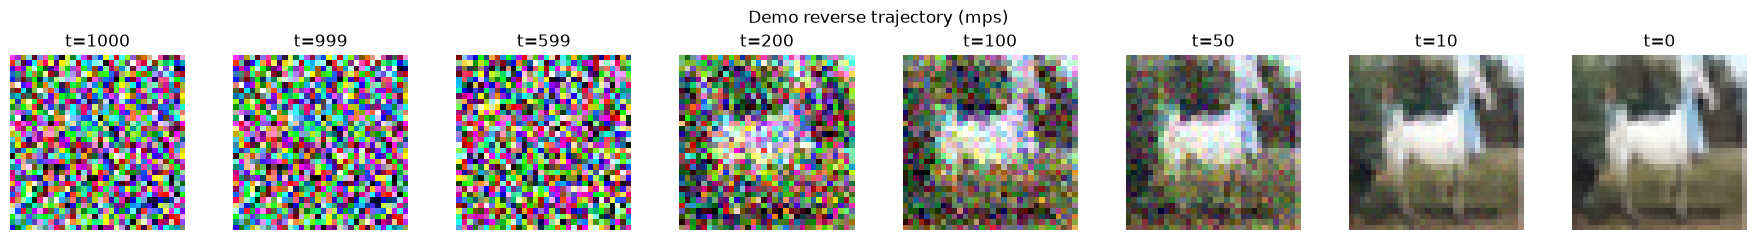

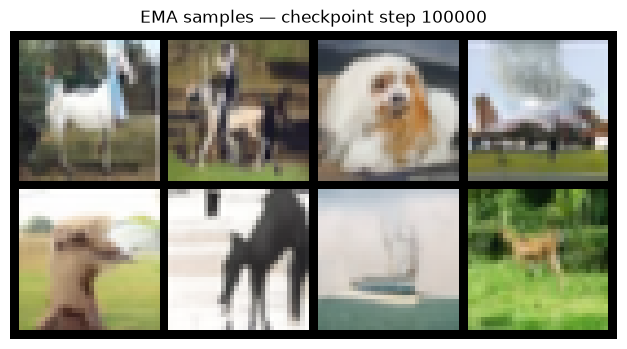

In [9]:
import importlib
import sys
from contextlib import nullcontext
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import torch
from torchvision.utils import make_grid

CUDA_DEMO_COUNT = 8
FALLBACK_DEMO_COUNT = 8
DEMO_SNAPSHOT_STEPS = (999, 599, 200, 100, 50, 10, 0)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "02_diffusion.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
checkpoint_path = PROJECT_ROOT / "checkpoints/ddpm_cifar10_production_ema.pt"

if torch.cuda.is_available():
    device = torch.device("cuda")
    demo_count = CUDA_DEMO_COUNT
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    demo_count = FALLBACK_DEMO_COUNT
else:
    device = torch.device("cpu")
    demo_count = FALLBACK_DEMO_COUNT

if checkpoint_path.exists():
    diffusion = importlib.import_module("02_diffusion")
    model_module = importlib.import_module("04_unet")

    payload = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    config_values = dict(payload["config"])
    config_values["data_dir"] = Path(config_values["data_dir"])
    config_values["checkpoint_dir"] = Path(config_values["checkpoint_dir"])
    cfg = SimpleNamespace(**config_values)

    schedule = diffusion.build_schedule(
        cfg.num_steps, cfg.beta_start, cfg.beta_end
    ).to(device)
    model = model_module.UNet(cfg).to(device).eval()
    model.load_state_dict(payload["ema_model"])

    seed = cfg.seed + 7
    torch.manual_seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)
    generator = (
        torch.Generator(device=device).manual_seed(seed)
        if device.type in {"cpu", "cuda"}
        else None
    )
    autocast_context = torch.autocast("cuda") if device.type == "cuda" else nullcontext()

    print(f"Generating {demo_count} image(s) on {device} with the 1,000-step sampler...")
    with autocast_context:
        demo_images, demo_snapshots = diffusion.sample_loop(
            model=model,
            schedule=schedule,
            batch_size=demo_count,
            channels=cfg.in_channels,
            image_size=cfg.image_size,
            device=device,
            snapshot_steps=DEMO_SNAPSHOT_STEPS,
            generator=generator,
            show_progress=True,
        )

    trajectory_steps = (cfg.num_steps, *DEMO_SNAPSHOT_STEPS)
    fig, axes = plt.subplots(1, len(trajectory_steps), figsize=(18, 2.4))
    for axis, step in zip(axes, trajectory_steps):
        image = diffusion.to_display(demo_snapshots[step][0])
        axis.imshow(image.permute(1, 2, 0).numpy())
        axis.set_title(f"t={step}")
        axis.axis("off")
    fig.suptitle(f"Demo reverse trajectory ({device})")
    fig.tight_layout()
    plt.show()

    display_images = diffusion.to_display(demo_images).cpu()
    grid = make_grid(display_images, nrow=min(4, demo_count))
    plt.figure(figsize=(8, 4) if demo_count > 1 else (4, 4))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(f"EMA samples — checkpoint step {payload['global_step']}")
    plt.axis("off")
    plt.show()
else:
    print(f"EMA checkpoint is missing: {checkpoint_path}")
    print("Use the committed reverse trajectory and sample grid below.")

### Reverse trajectory

<img src="../results/trajectory_production.png" alt="One image generated from Gaussian noise through reverse diffusion" width="1000"/>

The sampler starts at Gaussian noise (`t=1000`) and applies the U-Net sequentially from `999` to `0`. Coarse structure appears first; recognizable details become clear near the end.

### Fixed-seed sample grid

<img src="../results/samples_production.png" alt="64 generated CIFAR-10 samples" width="720"/>


## 10. Comparison and limitations

- This project: **FID 8.24 after 100,000 steps**.
- Ho et al.: **FID 3.17 after 800,000 steps** with the same 50,000-sample protocol and reference split.
- The paper's lower score is better, but it used **eight times more optimizer steps** and reported its best checkpoint.

Main limitations:

- Unconditional generation: no control over the requested class.
- Original 1,000-step DDPM sampling is slow.
- Compute limited the number of experiments and ablations.


## 11. Conclusion

- The forward process was implemented and checked numerically and visually.
- A time-conditioned U-Net learned to predict noise and reverse the process.
- The final model produced recognizable, diverse samples with **FID-50k 8.24**.

The main practical lesson was that DDPMs are conceptually simple but expensive to train and especially slow to sample with the original 1,000-step procedure.

### Literature

1. Ho, Jain, and Abbeel (2020), [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239).
2. Ronneberger, Fischer, and Brox (2015), [U-Net: Convolutional Networks for Biomedical Image Segmentation](https://arxiv.org/abs/1505.04597).
3. Krizhevsky (2009), [Learning Multiple Layers of Features from Tiny Images](https://www.cs.toronto.edu/~kriz/learning-features-2009-TR.pdf).

### Questions?

